# Data exploration — Prédiction du prix immobilier
## Notebook 01 : Analyse Exploratoire des Données

### Objectifs de ce Notebook

**ÉTAPE 1 : Séparation des Données Brutes et Exploration**
- 1.1 — Chargement du dataset brut et séparation train/test
- 1.2 — Aperçu des Données d'Entraînement
- 1.3 — Vérification des Doublons
- 1.4 — Valeurs Manquantes
- 1.5 — Types de Données & Complétude
- 1.6 — Statistiques Descriptives des Variables Numériques
- 1.7 — Échantillonnage Aléatoire
- 1.8 — Stratégies de Traitement des Valeurs Manquantes
- 1.9 — Analyse Univariée des Variables Catégorielles
- 1.10 — Détection des Outliers (Méthode IQR)
- 1.11 — Matrice de Corrélation (Variables Numériques)
- 1.12 — Analyse Bivariée : Prix de Vente par Variable Catégorielle
- 1.13 — Test Statistique : Significativité des Variables Catégorielles (ANOVA / Kruskal-Wallis)

**ÉTAPE 2 : Analyse de la Variable Cible (SALE PRICE)**
- Distribution des prix de vente, diagnostic de normalité et implications pour la modélisation

**Synthèse de l'Exploration**
- Qualité des données, insights clés et prochaines étapes (Notebook 02)

In [1]:
"""
Configuration de l'environnement — Prediction du prix immobilier
===================================================
Imports et configuration pour l'analyse exploratoire des données immobilières.
"""

import os
import psutil
import sys
import multiprocessing

# Nombre de cœurs disponibles
num_cores = multiprocessing.cpu_count()
print(f"Nombre de cœurs disponibles : {num_cores}")

# Nombre total de coeurs physiques
num_physical_cores = psutil.cpu_count(logical=True)

# Laisser un cœur libre pour le système
num_cores_to_use = max(1, num_physical_cores - 1)

# Manipulation des données
import pandas as pd
import numpy as np

# Statistiques et tests
import scipy.stats as ss

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Séparation des données
from sklearn.model_selection import train_test_split

# Seed pour la reproductibilité
RANDOM_STATE = 1204

# Import de la fonction utilitaire depuis utils/data_prep.py
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils.data_prep import detect_possible_outliers

print(" Imports chargés avec succès")

Nombre de cœurs disponibles : 16
 Imports chargés avec succès


In [2]:
# Vérification du répertoire de travail
print(f" Répertoire courant : {os.getcwd()}")

 Répertoire courant : c:\Users\juber\Documents\Scoring & prédiction de prix immobilier (Régression)\notebooks


---

# ÉTAPE 1 : Séparation des Données Brutes et Exploration

## Objectif
Charger les données immobilières, les séparer en jeu d'entraînement et de test, puis explorer leur structure, qualité et composition.

### 1.1 — Chargement du dataset brut et séparation train/test

### Questions à Répondre
- Quel est le volume du dataset ? (lignes / colonnes)
- Comment sont structurées les données ?
- Les types de colonnes sont-ils cohérents ?
- Y a-t-il des problèmes évidents ?

In [3]:
# ============================================================
# Chargement du dataset brut
# ============================================================
df = pd.read_csv("..\\data\\nyc-rolling-sales.csv")
print(f" Dataset importé : {df.shape[0]} lignes et {df.shape[1]} colonnes\n")

 Dataset importé : 84548 lignes et 22 colonnes



In [4]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84548 entries, 0 to 84547
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Unnamed: 0                      84548 non-null  int64 
 1   BOROUGH                         84548 non-null  int64 
 2   NEIGHBORHOOD                    84548 non-null  object
 3   BUILDING CLASS CATEGORY         84548 non-null  object
 4   TAX CLASS AT PRESENT            84548 non-null  object
 5   BLOCK                           84548 non-null  int64 
 6   LOT                             84548 non-null  int64 
 7   EASE-MENT                       84548 non-null  object
 8   BUILDING CLASS AT PRESENT       84548 non-null  object
 9   ADDRESS                         84548 non-null  object
 10  APARTMENT NUMBER                84548 non-null  object
 11  ZIP CODE                        84548 non-null  int64 
 12  RESIDENTIAL UNITS               84548 non-null

In [5]:
#Affichage des premières lignes du dataset
df.head()


,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,,C2,153 AVENUE B,...,5,0,5,1633,6440,1900,2,C2,6625000,2017-07-19 00:00:00
1,5,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,26,,C7,234 EAST 4TH STREET,...,28,3,31,4616,18690,1900,2,C7,-,2016-12-14 00:00:00
2,6,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,39,,C7,197 EAST 3RD STREET,...,16,1,17,2212,7803,1900,2,C7,-,2016-12-09 00:00:00
3,7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,,C4,154 EAST 7TH STREET,...,10,0,10,2272,6794,1913,2,C4,3936272,2016-09-23 00:00:00
4,8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,,C2,301 EAST 10TH STREET,...,6,0,6,2369,4615,1900,2,C2,8000000,2016-11-17 00:00:00


In [6]:
#Affichage d'une ligne aléatoire du dataset
df.sample()

,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
62375,12977,4,HOLLIS,01 ONE FAMILY DWELLINGS,1,10454,3,,A1,88-37 189TH STREET,...,1,0,1,4300,2230,1920,1,A1,-,2017-06-20 00:00:00


In [7]:
# ============================================================
# Séparation features / cible
# ============================================================
Target = "SALE PRICE"

# Conversion de la cible en numérique (valeurs comme " - " → NaN)
df[Target] = pd.to_numeric(df[Target], errors="coerce")

X = df.drop(columns=[Target])
y = df[Target]

# --- Train / Test Split (80/20) — Régression, pas de stratify ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# --- Limitation du jeu d'entraînement à 10 000 lignes max ---
MAX_TRAIN = 10_000
if len(X_train) > MAX_TRAIN:
    X_train = X_train.sample(n=MAX_TRAIN, random_state=RANDOM_STATE)
    y_train = y_train.loc[X_train.index]

# --- Affichage des dimensions ---
print("\n" + "=" * 70)
print("  DIMENSIONS DES DONNÉES")
print("=" * 70)
print(f"  Variables explicatives (X_train) : {X_train.shape}")
print(f"  Variable cible         (y_train) : {y_train.shape}")
print("-" * 70)
print(f"  Variables explicatives (X_test)  : {X_test.shape}")
print(f"  Variable cible         (y_test)  : {y_test.shape}")
print("=" * 70)


  DIMENSIONS DES DONNÉES
  Variables explicatives (X_train) : (10000, 21)
  Variable cible         (y_train) : (10000,)
----------------------------------------------------------------------
  Variables explicatives (X_test)  : (16910, 21)
  Variable cible         (y_test)  : (16910,)


In [8]:
# Identification des types de variables sur le jeu d'entraînement
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f" {len(cat_cols)} variables catégorielles : {cat_cols}\n")
print(f" {len(num_cols)} variables numériques    : {num_cols}\n")
print(f" Total : {len(cat_cols) + len(num_cols)} variables")

 11 variables catégorielles : ['NEIGHBORHOOD', 'BUILDING CLASS CATEGORY', 'TAX CLASS AT PRESENT', 'EASE-MENT', 'BUILDING CLASS AT PRESENT', 'ADDRESS', 'APARTMENT NUMBER', 'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'BUILDING CLASS AT TIME OF SALE', 'SALE DATE']

 10 variables numériques    : ['Unnamed: 0', 'BOROUGH', 'BLOCK', 'LOT', 'ZIP CODE', 'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS', 'YEAR BUILT', 'TAX CLASS AT TIME OF SALE']

 Total : 21 variables


In [9]:
# --- 1.2 — Aperçu des Données d'Entraînement ---
# Statistiques descriptives rapides de la variable cible
print(" APERÇU DE LA VARIABLE CIBLE — SALE PRICE (y_train)")
print("=" * 70)
print(f"  Nombre de transactions  : {y_train.shape[0]}")
print(f"  Valeurs manquantes      : {y_train.isna().sum()} ({y_train.isna().mean()*100:.2f}%)")
print(f"  Prix moyen              : ${y_train.mean():,.2f}")
print(f"  Prix médian             : ${y_train.median():,.2f}")
print(f"  Écart-type              : ${y_train.std():,.2f}")
print(f"  Min                     : ${y_train.min():,.2f}")
print(f"  Max                     : ${y_train.max():,.2f}")
print("=" * 70)

 APERÇU DE LA VARIABLE CIBLE — SALE PRICE (y_train)
  Nombre de transactions  : 10000
  Valeurs manquantes      : 1736 (17.36%)
  Prix moyen              : $1,264,562.51
  Prix médian             : $535,000.00
  Écart-type              : $6,006,004.63
  Min                     : $0.00
  Max                     : $268,124,175.00


In [10]:
# Histogramme de la distribution de SALE PRICE (y_train)
fig = px.histogram(
    y_train.dropna(),
    nbins=100,
    title="Distribution de SALE PRICE (y_train)",
    labels={"value": "Prix de vente ($)", "count": "Nombre de transactions"},
)

fig.update_layout(
    xaxis_title="Prix de vente ($)",
    yaxis_title="Nombre de transactions",
    showlegend=False,
    width=800,
    height=400
)

fig.show()

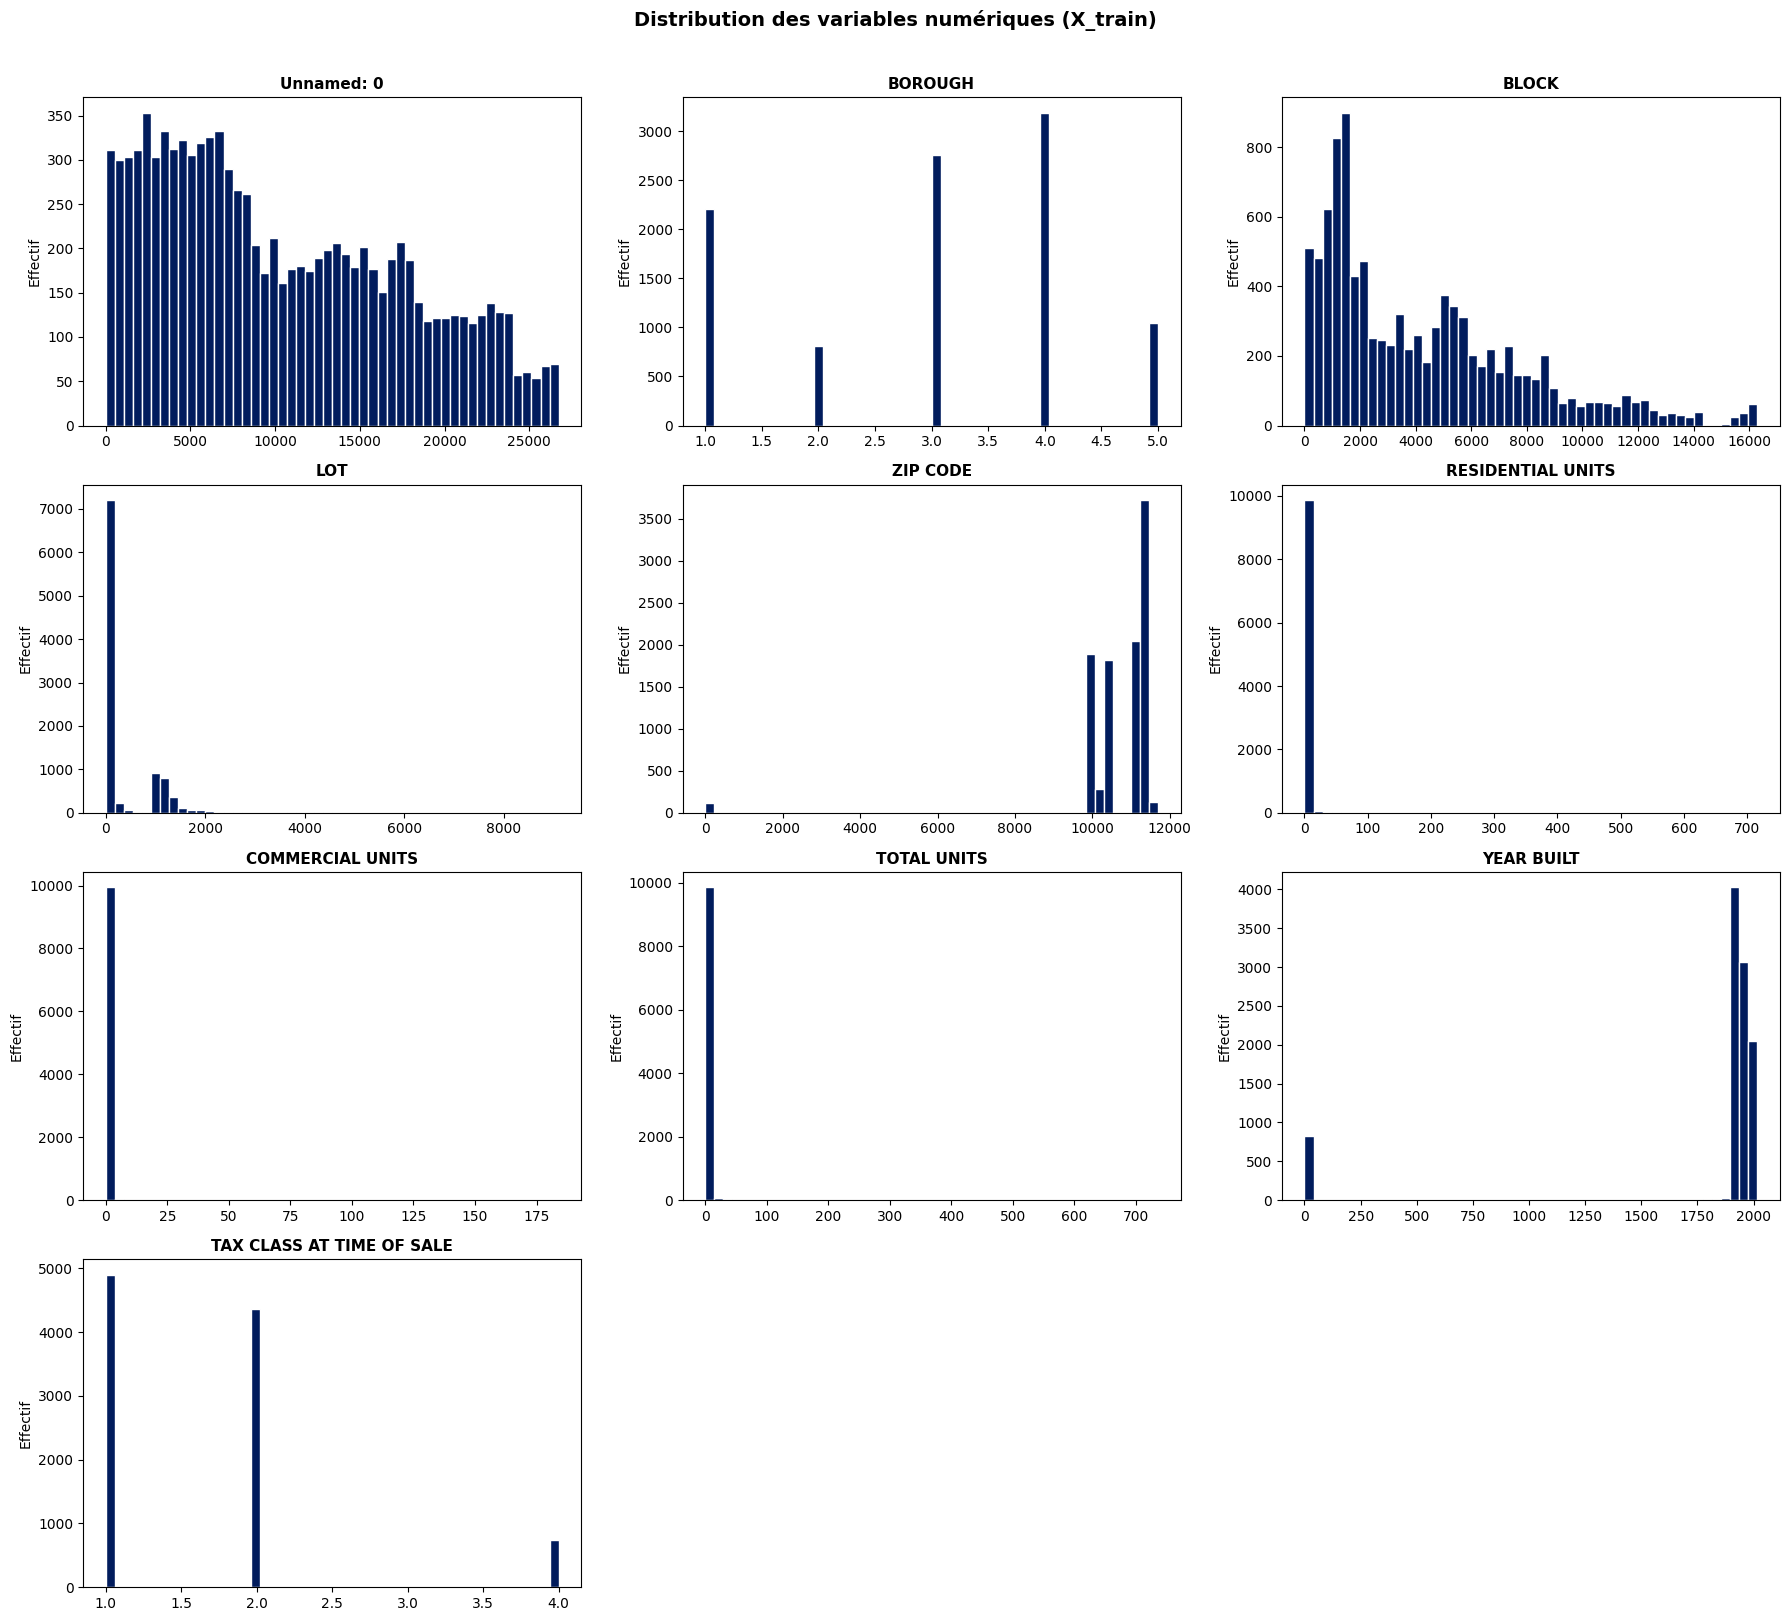

In [11]:
# Distributions des variables numériques (X_train) — Histogrammes
fig, axes = plt.subplots(
    nrows=(len(num_cols) + 2) // 3, ncols=3,
    figsize=(18, 4 * ((len(num_cols) + 2) // 3))
)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(X_train[col].dropna(), bins=50, color="#011c5d", edgecolor="white")
    axes[i].set_title(f"{col}", fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Effectif")

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution des variables numériques (X_train)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [12]:
# Aperçu des 5 premières lignes du jeu d'entraînement
print(" APERÇU DES 5 PREMIÈRES LIGNES (X_train)\n")
X_train.head()

 APERÇU DES 5 PREMIÈRES LIGNES (X_train)



,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE DATE
53115,3717,4,COLLEGE POINT,02 TWO FAMILY DWELLINGS,1,3956,22,,B1,5-23 128TH STREET,...,11356,2,0,2,3000,2380,1989,1,B1,2016-09-12 00:00:00
42041,16690,3,MARINE PARK,02 TWO FAMILY DWELLINGS,1,8484,35,,B3,1813 KIMBALL STREET,...,11234,2,0,2,4050,2338,1950,1,B3,2016-12-19 00:00:00
58250,8852,4,FLUSHING-NORTH,13 CONDOS - ELEVATOR APARTMENTS,2,5066,1111,,R4,"40-22 COLLEGE POINT BLVD.,",...,11354,1,0,1,-,-,0,2,R4,2017-06-15 00:00:00
34248,8897,3,CROWN HEIGHTS,02 TWO FAMILY DWELLINGS,1,1373,73,,B1,1465 STERLING PLACE,...,11213,2,0,2,2555,3492,1901,1,B1,2017-03-10 00:00:00
43435,18084,3,OCEAN PARKWAY-NORTH,02 TWO FAMILY DWELLINGS,1,6609,71,,B1,1623 EAST 2ND STREET,...,11230,2,0,2,2825,2600,1920,1,B1,2016-11-10 00:00:00


In [13]:
# Vérification des doublons sur le jeu d'entraînement
print("\n" + "=" * 70)
print("  VÉRIFICATION DES DOUBLONS (X_train)")
print("=" * 70 + "\n")

# Doublons exacts
n_doublons_exacts = X_train.duplicated().sum()
pct_doublons_exacts = (n_doublons_exacts / len(X_train)) * 100
print(f" Doublons exacts (toutes colonnes)           : {n_doublons_exacts} ({pct_doublons_exacts:.2f}%)")

# Doublons sans tenir compte de Unnamed: 0 (supposé unique)
if "Unnamed: 0" in X_train.columns:
    n_doublons_no_id = X_train.duplicated(subset=X_train.columns.difference(["Unnamed: 0"])).sum()
    pct_doublons_no_id = (n_doublons_no_id / len(X_train)) * 100
    print(f" Doublons (hors Unnamed: 0)                  : {n_doublons_no_id} ({pct_doublons_no_id:.2f}%)")

print("\n" + "=" * 70)


  VÉRIFICATION DES DOUBLONS (X_train)

 Doublons exacts (toutes colonnes)           : 0 (0.00%)
 Doublons (hors Unnamed: 0)                  : 30 (0.30%)



In [14]:
# Analyse des valeurs manquantes sur X_train
print("\n" + "=" * 70)
print("  ANALYSE DES VALEURS MANQUANTES (X_train)")
print("=" * 70 + "\n")

missing_data = pd.DataFrame({
    "Colonne": X_train.columns,
    "Manquantes": X_train.isnull().sum().values,
    "Pourcentage": (X_train.isnull().sum().values / len(X_train) * 100).round(2)
})

missing_data_filtered = missing_data[missing_data["Manquantes"] > 0].sort_values("Manquantes", ascending=False)

if len(missing_data_filtered) > 0:
    print("  Colonnes avec valeurs manquantes :\n")
    display(missing_data_filtered.reset_index(drop=True))
else:
    print(" Aucune valeur manquante détectée dans X_train !")

print(f"\n Total de cellules manquantes     : {X_train.isnull().sum().sum()}")
print(f" Pourcentage global de complétude : {(1 - X_train.isnull().sum().sum() / (X_train.shape[0] * X_train.shape[1])) * 100:.2f}%")
print("\n" + "=" * 70)


  ANALYSE DES VALEURS MANQUANTES (X_train)

 Aucune valeur manquante détectée dans X_train !

 Total de cellules manquantes     : 0
 Pourcentage global de complétude : 100.00%



In [15]:
# Types de données et complétude sur X_train
print("\n" + "=" * 70)
print("  INFORMATIONS SUR LES COLONNES & TYPES DE DONNÉES (X_train)")
print("=" * 70 + "\n")

info_df = pd.DataFrame({
    "Colonne": X_train.columns,
    "Type": X_train.dtypes.values,
    "Non-Null": X_train.notnull().sum().values,
    "Null": X_train.isnull().sum().values,
    "Null %": (X_train.isnull().sum().values / len(X_train) * 100).round(2)
})
display(info_df)

print("\n RÉSUMÉ DES TYPES :")
print(f"   • Variables numériques (int/float) : {X_train.select_dtypes(include=[np.number]).shape[1]}")
print(f"   • Variables catégorielles (object)  : {X_train.select_dtypes(include=['object']).shape[1]}")
print(f"   • Complétude globale              : {(1 - X_train.isnull().sum().sum() / (X_train.shape[0] * X_train.shape[1])) * 100:.2f}%")


  INFORMATIONS SUR LES COLONNES & TYPES DE DONNÉES (X_train)



,Colonne,Type,Non-Null,Null,Null %
0,Unnamed: 0,int64,10000,0,0.0
1,BOROUGH,int64,10000,0,0.0
2,NEIGHBORHOOD,object,10000,0,0.0
3,BUILDING CLASS CATEGORY,object,10000,0,0.0
4,TAX CLASS AT PRESENT,object,10000,0,0.0
5,BLOCK,int64,10000,0,0.0
6,LOT,int64,10000,0,0.0
7,EASE-MENT,object,10000,0,0.0
8,BUILDING CLASS AT PRESENT,object,10000,0,0.0
9,ADDRESS,object,10000,0,0.0



 RÉSUMÉ DES TYPES :
   • Variables numériques (int/float) : 10
   • Variables catégorielles (object)  : 11
   • Complétude globale              : 100.00%


In [16]:
# Statistiques descriptives des variables numériques (X_train)
print("\n" + "=" * 70)
print("  STATISTIQUES DESCRIPTIVES — VARIABLES NUMÉRIQUES (X_train)")
print("=" * 70 + "\n")

X_train[num_cols].describe().round(2)


  STATISTIQUES DESCRIPTIVES — VARIABLES NUMÉRIQUES (X_train)



,Unnamed: 0,BOROUGH,BLOCK,LOT,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,YEAR BUILT,TAX CLASS AT TIME OF SALE
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0,10000.00
mean,10286.76,3.01,4223.68,375.12,10720.36,1.96,0.16,2.15,1788.4,1.66
std,7127.49,1.30,3574.38,675.14,1312.79,12.08,2.93,12.67,538.7,0.82
min,5.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.0,1.00
25%,4247.75,2.00,1325.75,22.00,10304.00,0.00,0.00,1.00,1920.0,1.00
50%,8694.50,3.00,3279.00,50.00,11208.00,1.00,0.00,1.00,1940.0,2.00
75%,15842.75,4.00,6225.50,630.75,11357.00,2.00,0.00,2.00,1965.0,2.00
max,26737.00,5.00,16296.00,9106.00,11694.00,716.00,184.00,736.00,2017.0,4.00


In [17]:
# Boxplots interactifs des variables numériques (X_train)
fig = make_subplots(
    rows=1, cols=len(num_cols),
    subplot_titles=num_cols
)

for i, col in enumerate(num_cols, 1):
    fig.add_trace(
        go.Box(y=X_train[col], name=col, marker_color="#011c5d"),
        row=1, col=i
    )

fig.update_layout(
    title_text="Boxplots des variables numériques (X_train)",
    height=500,
    width=300 * len(num_cols),
    showlegend=False
)

fig.show()

In [18]:
# Échantillon aléatoire pour validation de cohérence (X_train)
print(" APERÇU DE 10 LIGNES ALÉATOIRES (X_train)\n")
X_train.sample(10, random_state=42)

 APERÇU DE 10 LIGNES ALÉATOIRES (X_train)



,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE DATE
44972,19621,3,PARK SLOPE,15 CONDOS - 2-10 UNIT RESIDENTIAL,2C,936,1008,,R1,85 6TH AVENUE,...,11217,1,0,1,0,0,1900,2,R1,2017-04-07 00:00:00
208,212,1,CHELSEA,01 ONE FAMILY DWELLINGS,1,772,29,,A4,231 WEST 22ND STREET,...,10011,1,0,1,1588,5653,1900,1,A4,2017-01-30 00:00:00
44685,19334,3,PARK SLOPE,09 COOPS - WALKUP APARTMENTS,2C,1006,30,,C6,"392 EIGHTH STREET, 3L",...,11215,0,0,0,0,0,1905,2,C6,2017-01-10 00:00:00
2031,2035,1,FASHION,13 CONDOS - ELEVATOR APARTMENTS,2,838,1137,,R4,400 5 AVENUE,...,10018,1,0,1,-,-,2010,2,R4,2017-07-22 00:00:00
20172,1870,2,FORDHAM,02 TWO FAMILY DWELLINGS,1,3178,10,,B1,2072 WALTON AVENUE,...,10453,2,0,2,2536,2032,1901,1,B1,2016-11-18 00:00:00
79227,3093,5,HUGUENOT,01 ONE FAMILY DWELLINGS,1,6574,49,,A1,158 KINGDOM AVENUE,...,10312,1,0,1,4000,2137,1930,1,A1,2017-03-31 00:00:00
77443,1309,5,CONCORD,02 TWO FAMILY DWELLINGS,1,2898,6,,B2,334 MOSEL AVENUE,...,10304,2,0,2,5000,1720,1930,1,B2,2016-11-18 00:00:00
42867,17516,3,OCEAN HILL,02 TWO FAMILY DWELLINGS,1,1496,13,,B3,718 MACON STREET,...,11233,2,0,2,1800,2430,1899,1,B3,2017-07-31 00:00:00
65184,15786,4,KEW GARDENS,02 TWO FAMILY DWELLINGS,1,3321,11,,S2,116-22 116TH STREET,...,11420,2,1,3,2268,3696,1975,1,S2,2016-12-06 00:00:00
41327,15976,3,MADISON,01 ONE FAMILY DWELLINGS,1,7291,25,,A1,1960 HOMECREST AVENUE,...,11229,1,0,1,3080,2125,1930,1,A1,2017-07-26 00:00:00


In [19]:
# Analyse détaillée des valeurs manquantes et recommandations
print("\n" + "=" * 70)
print("  STRATÉGIE DE TRAITEMENT DES VALEURS MANQUANTES (X_train)")
print("=" * 70 + "\n")

missing_analysis = pd.DataFrame({
    "Colonne": X_train.columns,
    "Manquants": X_train.isnull().sum().values,
    "Manquants %": (X_train.isnull().sum().values / len(X_train) * 100).round(2),
    "Status": [" OK" if x == 0 else "  À traiter" for x in X_train.isnull().sum().values]
})

missing_analysis = missing_analysis[missing_analysis["Manquants"] > 0].sort_values("Manquants", ascending=False)

if len(missing_analysis) == 0:
    print(" EXCELLENT : Aucune valeur manquante détectée dans X_train !")
    print("   Le dataset est complet et prêt pour la modélisation.")
else:
    print("  VALEURS MANQUANTES DÉTECTÉES :\n")
    display(missing_analysis)
    print("\n RECOMMANDATIONS :")
    for _, row in missing_analysis.iterrows():
        pct = row["Manquants %"]
        if pct < 1:
            print(f"   • {row['Colonne']} ({pct}%) : Supprimer les lignes")
        elif pct < 5:
            print(f"   • {row['Colonne']} ({pct}%) : Imputer (moyenne/médiane/mode)")
        elif pct < 30:
            print(f"   • {row['Colonne']} ({pct}%) : Analyser le pattern d'absence")
        else:
            print(f"   • {row['Colonne']} ({pct}%) :  Considérer la suppression")


  STRATÉGIE DE TRAITEMENT DES VALEURS MANQUANTES (X_train)

 EXCELLENT : Aucune valeur manquante détectée dans X_train !
   Le dataset est complet et prêt pour la modélisation.


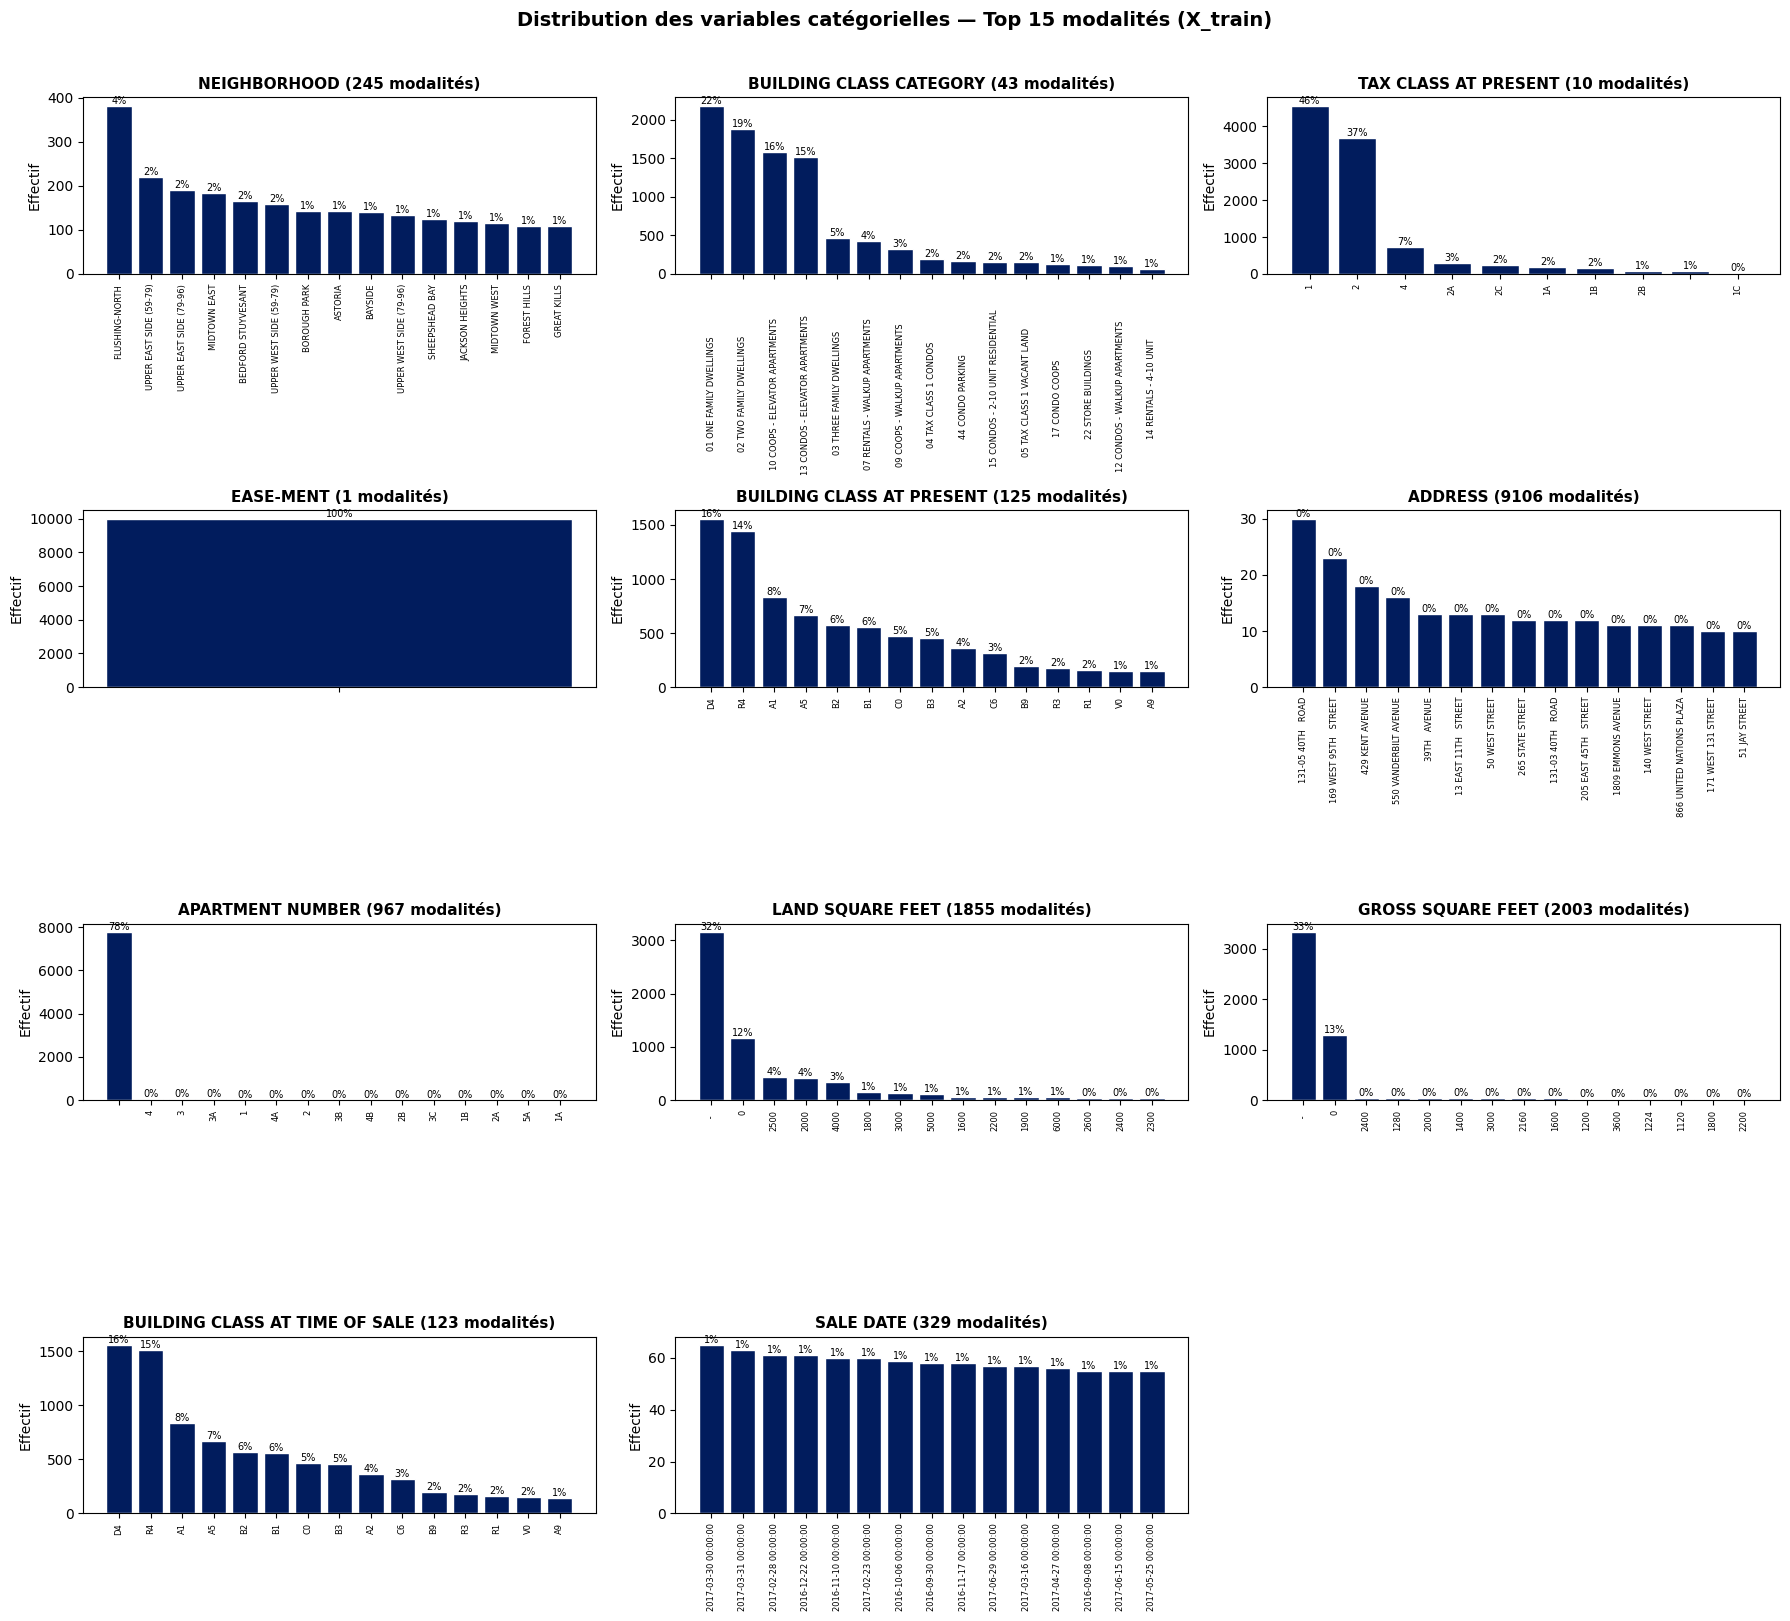

In [20]:
# Distribution des variables catégorielles (X_train)
cat_cols_analysis = cat_cols.copy()

n_cols_plot = 3
n_rows_plot = (len(cat_cols_analysis) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(cat_cols_analysis):
    counts = X_train[col].value_counts().head(15)  # Top 15 modalités
    bars = axes[i].bar(range(len(counts)), counts.values, color="#011c5d", edgecolor="white")
    axes[i].set_title(f"{col} ({X_train[col].nunique()} modalités)", fontsize=11, fontweight="bold")
    axes[i].set_xticks(range(len(counts)))
    axes[i].set_xticklabels(counts.index, rotation=90, ha="center", fontsize=6)  # <- modifié ici
    axes[i].set_ylabel("Effectif")

    # Annotation des pourcentages
    total = X_train[col].value_counts().sum()
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                     f"{val / total:.0%}", ha="center", va="bottom", fontsize=7)

# Masquer les axes inutilisés
for j in range(len(cat_cols_analysis), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution des variables catégorielles — Top 15 modalités (X_train)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [21]:
# Détection des outliers avec la fonction importée de utils/data_prep.py
print("\n" + "=" * 70)
print("  DÉTECTION DES OUTLIERS — MÉTHODE IQR (X_train)")
print("=" * 70 + "\n")

outlier_summary = []

for col in num_cols:
    outlier_idx, lower, upper = detect_possible_outliers(X_train, col)
    n_outliers = len(outlier_idx)
    pct = (n_outliers / len(X_train)) * 100
    outlier_summary.append({
        "Variable": col,
        "Nb Outliers": n_outliers,
        "% du train": round(pct, 2),
        "Borne basse": round(lower, 2),
        "Borne haute": round(upper, 2),
        "Min réel": round(X_train[col].min(), 2),
        "Max réel": round(X_train[col].max(), 2)
    })
    status = "" if n_outliers > 0 else ""
    print(f"  {status} {col:<25s} : {n_outliers:>5d} outliers ({pct:.1f}%)  |  bornes [{lower:.1f} ; {upper:.1f}]")

outlier_df = pd.DataFrame(outlier_summary)

print("\n Note : Certains outliers peuvent refléter des biens de luxe ou")
print("   des transactions atypiques — à analyser avant suppression.")


  DÉTECTION DES OUTLIERS — MÉTHODE IQR (X_train)

   Unnamed: 0                :     0 outliers (0.0%)  |  bornes [-13144.8 ; 33235.2]
   BOROUGH                   :     0 outliers (0.0%)  |  bornes [-1.0 ; 7.0]
   BLOCK                     :   200 outliers (2.0%)  |  bornes [-6023.9 ; 13575.1]
   LOT                       :   333 outliers (3.3%)  |  bornes [-891.1 ; 1543.9]
   ZIP CODE                  :   121 outliers (1.2%)  |  bornes [8724.5 ; 12936.5]
   RESIDENTIAL UNITS         :   340 outliers (3.4%)  |  bornes [-3.0 ; 5.0]
   COMMERCIAL UNITS          :   620 outliers (6.2%)  |  bornes [0.0 ; 0.0]
   TOTAL UNITS               :   604 outliers (6.0%)  |  bornes [-0.5 ; 3.5]
   YEAR BUILT                :   840 outliers (8.4%)  |  bornes [1852.5 ; 2032.5]
   TAX CLASS AT TIME OF SALE :   734 outliers (7.3%)  |  bornes [-0.5 ; 3.5]

 Note : Certains outliers peuvent refléter des biens de luxe ou
   des transactions atypiques — à analyser avant suppression.


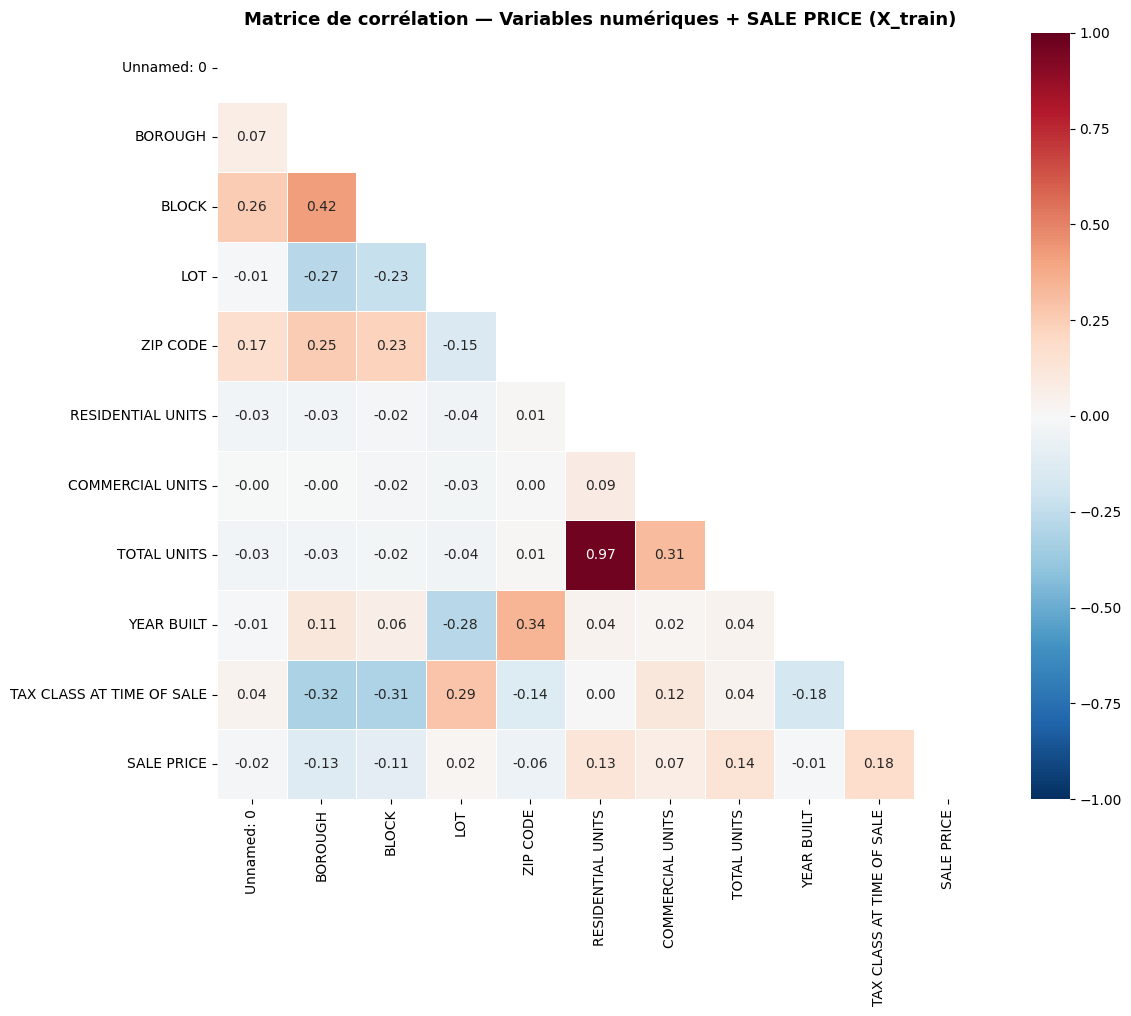


 Corrélations avec SALE PRICE :
   TAX CLASS AT TIME OF SALE : +0.180  (modérée)
   TOTAL UNITS               : +0.140  (faible)
   BOROUGH                   : -0.129  (faible)
   RESIDENTIAL UNITS         : +0.128  (faible)
   BLOCK                     : -0.108  (faible)
   COMMERCIAL UNITS          : +0.074  (faible)
   ZIP CODE                  : -0.058  (faible)
   Unnamed: 0                : -0.020  (faible)
   LOT                       : +0.020  (faible)
   YEAR BUILT                : -0.011  (faible)


In [22]:
# Matrice de corrélation — variables numériques + cible (SALE PRICE)
train_corr = X_train[num_cols].copy()
train_corr[Target] = y_train.values

corr_matrix = train_corr.corr()

# Heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True
)
plt.title("Matrice de corrélation — Variables numériques + SALE PRICE (X_train)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Corrélations avec la cible
print("\n Corrélations avec SALE PRICE :")
price_corr = corr_matrix[Target].drop(Target).sort_values(key=abs, ascending=False)
for var, val in price_corr.items():
    signe = "+" if val > 0 else ""
    force = "forte" if abs(val) > 0.3 else "modérée" if abs(val) > 0.15 else "faible"
    print(f"   {var:<25s} : {signe}{val:.3f}  ({force})")

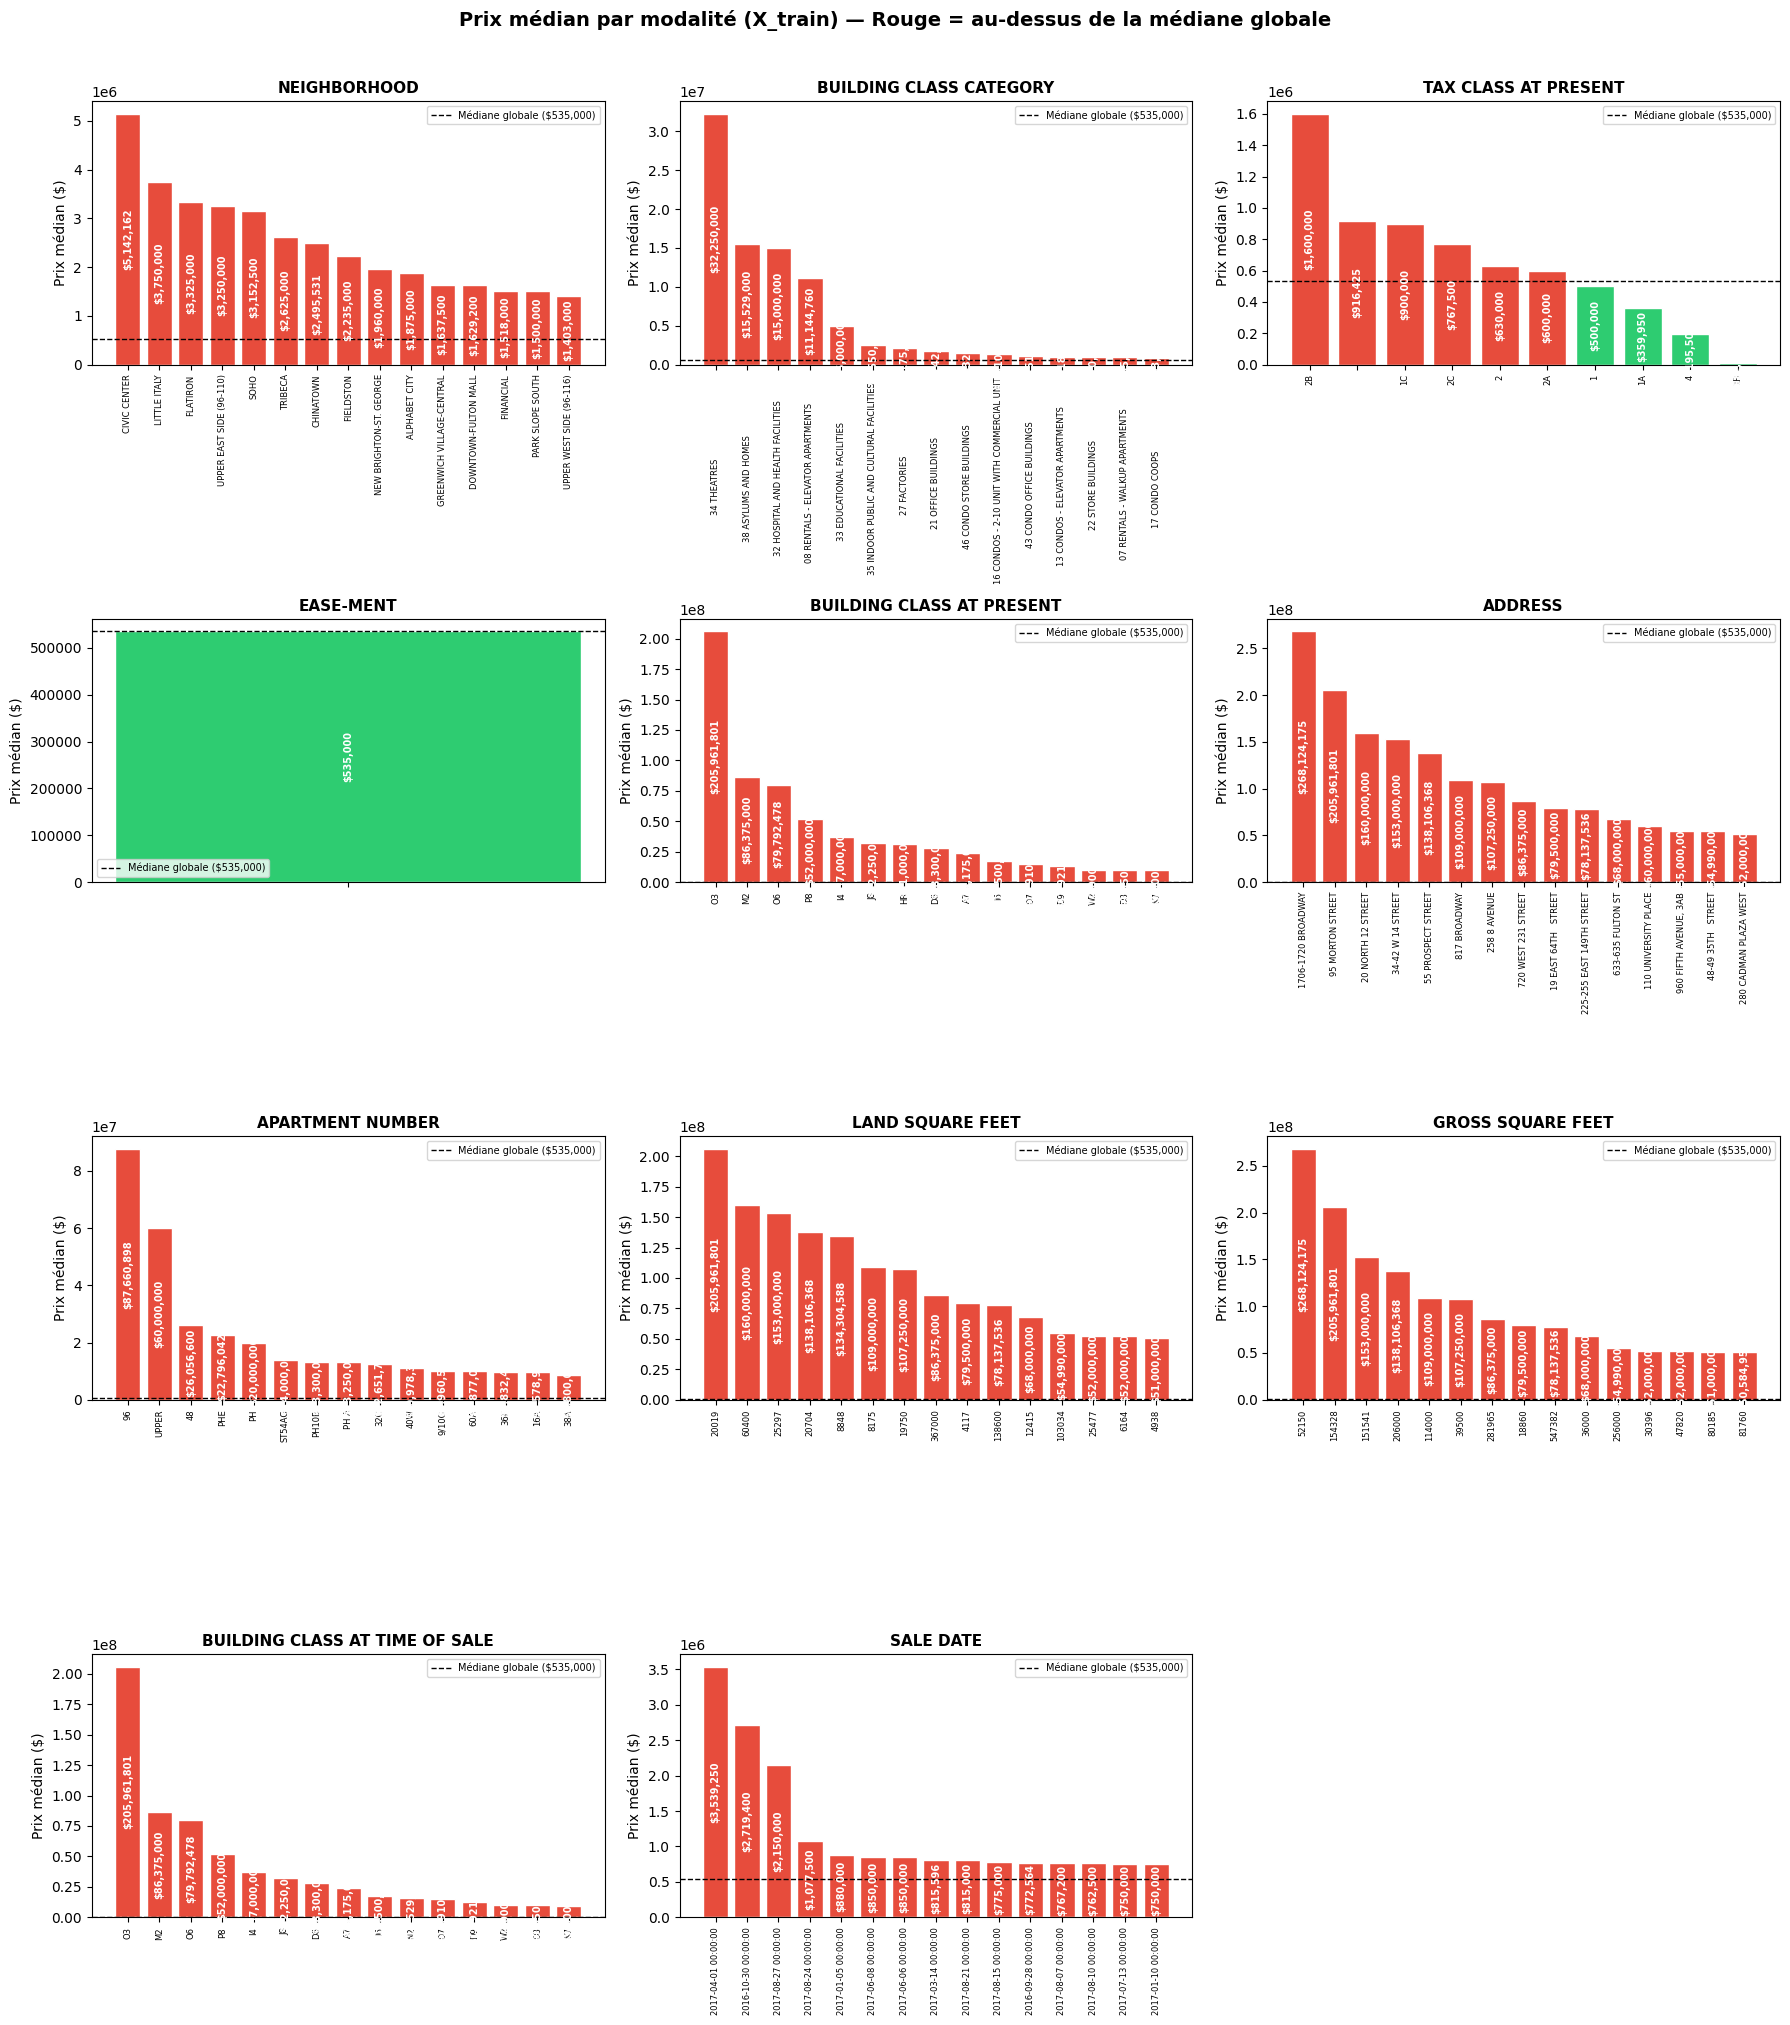

In [23]:
# Prix médian par variable catégorielle (X_train)
cat_cols_analysis = cat_cols.copy()

# Préparer les données : concaténer X_train avec y_train
train_analysis = X_train.copy()
train_analysis[Target] = y_train.values
prix_median_global = train_analysis[Target].median()

n_cols_plot = 3
n_rows_plot = (len(cat_cols_analysis) + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 5 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(cat_cols_analysis):
    # Calcul du prix médian par modalité (top 15)
    median_prices = train_analysis.groupby(col)[Target].median().sort_values(ascending=False).head(15)

    bars = axes[i].bar(
        range(len(median_prices)),
        median_prices.values,
        color=["#e74c3c" if v > prix_median_global else "#2ecc71" for v in median_prices.values],
        edgecolor="white"
    )

    axes[i].axhline(
        y=prix_median_global,
        color="black",
        linestyle="--",
        linewidth=1,
        label=f"Médiane globale (${prix_median_global:,.0f})"
    )

    axes[i].set_title(f"{col}", fontsize=11, fontweight="bold")
    axes[i].set_xticks(range(len(median_prices)))
    axes[i].set_xticklabels(
        median_prices.index,
        rotation=90,   # <- vertical
        ha="center",   # <- centré sous la barre
        fontsize=6     # <- police plus petite
    )
    axes[i].set_ylabel("Prix médian ($)")
    axes[i].legend(fontsize=7)

    # Texte vertical sur les barres
    for bar, val in zip(bars, median_prices.values):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 0.5,
            f"${val:,.0f}",
            ha="center",
            va="center",
            rotation=90,
            fontsize=7,
            fontweight="bold",
            color="white"
        )

# Masquer les axes inutilisés
for j in range(len(cat_cols_analysis), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Prix médian par modalité (X_train) — Rouge = au-dessus de la médiane globale",
    fontsize=14,
    fontweight="bold",
    y=1.01
)

plt.tight_layout()
plt.show()

In [24]:
# Test Kruskal-Wallis pour chaque variable catégorielle vs SALE PRICE
print("\n" + "=" * 70)
print("  TEST DE KRUSKAL-WALLIS — ASSOCIATION AVEC SALE PRICE (X_train)")
print("=" * 70 + "\n")

alpha = 0.05
kruskal_results = []

train_analysis = X_train.copy()
train_analysis[Target] = y_train.values

for col in cat_cols_analysis:
    # Grouper les prix par modalité (exclure NaN)
    groups = [group[Target].dropna().values for _, group in train_analysis.groupby(col) if len(group[Target].dropna()) > 1]

    if len(groups) >= 2:
        stat, p_value = ss.kruskal(*groups)
        significant = " Significatif" if p_value < alpha else " Non significatif"
        kruskal_results.append({
            "Variable": col,
            "Statistique H": round(stat, 2),
            "p-value": f"{p_value:.2e}" if p_value < 0.001 else f"{p_value:.4f}",
            "Nb modalités": train_analysis[col].nunique(),
            "Résultat": significant
        })

kruskal_df = pd.DataFrame(kruskal_results).sort_values("Statistique H", ascending=False)
display(kruskal_df.reset_index(drop=True))

n_signif = sum(1 for r in kruskal_results if "Significatif" in r["Résultat"] and "Non" not in r["Résultat"])
print(f"\n {n_signif}/{len(kruskal_results)} variables catégorielles ont un effet significatif sur SALE PRICE (α = {alpha})")
print("   Test non paramétrique : pas d'hypothèse de normalité requise.")


  TEST DE KRUSKAL-WALLIS — ASSOCIATION AVEC SALE PRICE (X_train)



,Variable,Statistique H,p-value,Nb modalités,Résultat
0,NEIGHBORHOOD,2481.03,0.00e+00,245,Significatif
1,BUILDING CLASS AT TIME OF SALE,1498.83,1.41e-256,123,Significatif
2,BUILDING CLASS AT PRESENT,1466.99,4.69e-250,125,Significatif
3,BUILDING CLASS CATEGORY,1282.16,3.46e-245,43,Significatif
4,GROSS SQUARE FEET,1228.72,2.60e-32,2003,Significatif
5,LAND SQUARE FEET,986.38,5.38e-42,1855,Significatif
6,ADDRESS,767.09,1.17e-41,9106,Significatif
7,APARTMENT NUMBER,674.34,4.90e-40,967,Significatif
8,TAX CLASS AT PRESENT,433.46,9.84e-88,10,Significatif
9,SALE DATE,399.77,6.96e-07,329,Significatif



 10/10 variables catégorielles ont un effet significatif sur SALE PRICE (α = 0.05)
   Test non paramétrique : pas d'hypothèse de normalité requise.


In [25]:
# ============================================================
# ÉTAPE 2 : Analyse de la Variable Cible (SALE PRICE)
# ============================================================
print("\n" + "=" * 70)
print("  ANALYSE DE LA VARIABLE CIBLE : SALE PRICE (y_train)")
print("=" * 70 + "\n")

y_clean = y_train.dropna()
y_positive = y_clean[y_clean > 0]

print(f"  Nombre total de transactions     : {len(y_train):,}")
print(f"  Valeurs manquantes (NaN)         : {y_train.isna().sum():,} ({y_train.isna().mean()*100:.2f}%)")
print(f"  Transactions à $0                : {(y_clean == 0).sum():,}")
print(f"  Transactions valides (> $0)      : {len(y_positive):,}")

print(f"\n  --- Statistiques sur prix > $0 ---")
print(f"  Prix moyen                       : ${y_positive.mean():,.2f}")
print(f"  Prix médian                      : ${y_positive.median():,.2f}")
print(f"  Écart-type                       : ${y_positive.std():,.2f}")
print(f"  Min                              : ${y_positive.min():,.2f}")
print(f"  Max                              : ${y_positive.max():,.2f}")

# Diagnostic de normalité
skewness = y_positive.skew()
kurtosis = y_positive.kurtosis()
print(f"\n  Skewness (asymétrie)             : {skewness:.2f}")
print(f"  Kurtosis (aplatissement)         : {kurtosis:.2f}")

if abs(skewness) > 2:
    print("    Distribution TRÈS asymétrique → transformation log recommandée")
elif abs(skewness) > 1:
    print("    Distribution asymétrique → envisager une transformation")
else:
    print("    Distribution raisonnablement symétrique")

# Rapport moyenne/médiane
ratio = y_positive.mean() / y_positive.median()
print(f"\n  Ratio Moyenne/Médiane            : {ratio:.2f}")
if ratio > 1.5:
    print("    Forte présence de valeurs élevées tirant la moyenne vers le haut")
    print("    → La médiane est un meilleur indicateur de tendance centrale")

print("\n" + "=" * 70)


  ANALYSE DE LA VARIABLE CIBLE : SALE PRICE (y_train)

  Nombre total de transactions     : 10,000
  Valeurs manquantes (NaN)         : 1,736 (17.36%)
  Transactions à $0                : 1,154
  Transactions valides (> $0)      : 7,110

  --- Statistiques sur prix > $0 ---
  Prix moyen                       : $1,469,809.36
  Prix médian                      : $630,000.00
  Écart-type                       : $6,451,816.64
  Min                              : $1.00
  Max                              : $268,124,175.00

  Skewness (asymétrie)             : 23.20
  Kurtosis (aplatissement)         : 715.98
    Distribution TRÈS asymétrique → transformation log recommandée

  Ratio Moyenne/Médiane            : 2.33
    Forte présence de valeurs élevées tirant la moyenne vers le haut
    → La médiane est un meilleur indicateur de tendance centrale



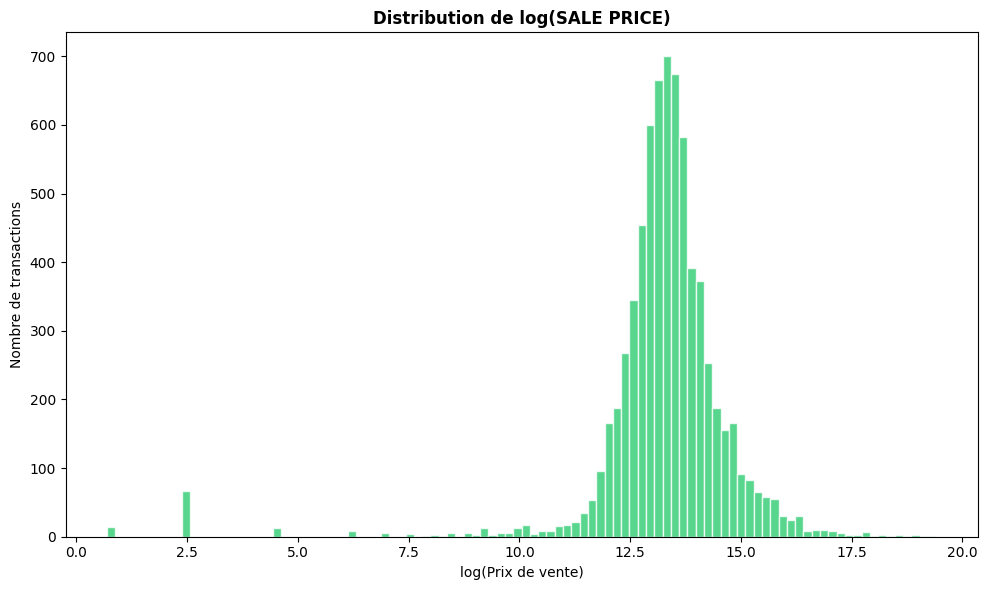

In [26]:
# Visualisation de la distribution log de SALE PRICE (y_train)
y_positive = y_train[y_train > 0].dropna()

plt.figure(figsize=(10,6))

plt.hist(np.log1p(y_positive), bins=100, color="#2ecc71", edgecolor="white", alpha=0.8)

plt.title("Distribution de log(SALE PRICE)", fontsize=12, fontweight="bold")
plt.xlabel("log(Prix de vente)")
plt.ylabel("Nombre de transactions")

plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# SYNTHÈSE DE L'EXPLORATION
# ============================================================
print("\n" + "=" * 70)
print("  SYNTHÈSE & IMPLICATIONS POUR LA MODÉLISATION")
print("=" * 70 + "\n")

y_positive = y_train[y_train > 0].dropna()
skewness = y_positive.skew()

print(" STRATÉGIES À ENVISAGER :\n")

# 1. Transformation de la cible
print("1  TRANSFORMATION DE LA CIBLE")
if abs(skewness) > 2:
    print("   La distribution de SALE PRICE est TRÈS asymétrique.")
    print("    Option A : Transformation log(y) pour normaliser")
    print("    Option B : Transformation Box-Cox")
    print("    Ne pas oublier l'inverse (exp) pour les prédictions finales")
else:
    print("   La distribution est raisonnablement symétrique.")
    print("    Pas de transformation nécessaire a priori")

# 2. Métriques d'évaluation
print("\n2  MÉTRIQUES D'ÉVALUATION (RÉGRESSION)")
print("    RMSE : pénalise les grosses erreurs")
print("    MAE  : robuste aux outliers")
print("    R²   : variance expliquée par le modèle")
print("    MAPE : erreur en pourcentage (interprétable métier)")

# 3. Gestion des outliers
print("\n3  GESTION DES OUTLIERS")
print("   Les biens de luxe créent des outliers naturels.")
print("    Option A : Cap les prix extrêmes (winsorization)")
print("    Option B : Modéliser sur log(prix) pour réduire l'impact")
print("    Option C : Segmenter luxe vs standard")

# 4. Score de valorisation (objectif métier)
print("\n4  SCORE DE VALORISATION (OBJECTIF MÉTIER)")
print("   Le modèle prédit un prix théorique → comparer au prix réel.")
print("    Score = (Prix réel - Prix prédit) / Prix prédit × 100")
print("    • Score > 0 : bien en SURCOTE (vendu au-dessus de l'estimation)")
print("    • Score < 0 : bien en DÉCOTE (opportunité d'investissement)")

# 5. Prochaines étapes
print("\n5  PROCHAINES ÉTAPES (Notebook 02)")
if len(y_train) < 5000:
    print("     Dataset petit : envisager un split 70-30 pour maximiser le train")
else:
    print("    Dataset suffisamment grand pour un split 80-20")
print("    Feature engineering (encodage, interactions, création de variables)")
print("    Modèle baseline (régression linéaire, XGBoost, Random Forest)")
print("    Optimisation des hyperparamètres")

print("\n" + "=" * 70)


  SYNTHÈSE & IMPLICATIONS POUR LA MODÉLISATION

 STRATÉGIES À ENVISAGER :

1  TRANSFORMATION DE LA CIBLE
   La distribution de SALE PRICE est TRÈS asymétrique.
    Option A : Transformation log(y) pour normaliser
    Option B : Transformation Box-Cox
    Ne pas oublier l'inverse (exp) pour les prédictions finales

2  MÉTRIQUES D'ÉVALUATION (RÉGRESSION)
    RMSE : pénalise les grosses erreurs
    MAE  : robuste aux outliers
    R²   : variance expliquée par le modèle
    MAPE : erreur en pourcentage (interprétable métier)

3  GESTION DES OUTLIERS
   Les biens de luxe créent des outliers naturels.
    Option A : Cap les prix extrêmes (winsorization)
    Option B : Modéliser sur log(prix) pour réduire l'impact
    Option C : Segmenter luxe vs standard

4  SCORE DE VALORISATION (OBJECTIF MÉTIER)
   Le modèle prédit un prix théorique → comparer au prix réel.
    Score = (Prix réel - Prix prédit) / Prix prédit × 100
    • Score > 0 : bien en SURCOTE (vendu au-dessus de l'estimation)
    • S